In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [80]:
####
##READ DAILY DATA, CLEAN
####

#Read USGS north arm gage
gage_readings = r"USGS//Daily_Combined.csv"
df = pd.read_csv(gage_readings)

#remove columns we dont care about
df = df.drop(columns=["x","y","id","time_series_id",'monitoring_location_id', 'parameter_code',
       'statistic_id','last_modified','approval_status', 'qualifier'])
df.columns = ["date",'elev','unit'] #renaming columns

#add 3.475 to convert to the correct datum, convert to meters
df['elevft'] = (df['elev'] + 3.47585958) #datum conversion
df['elev'] = df['elevft']  * 0.3048 #convert to meters

#sort by date, remove duplicate values (i manually combined tables for 2013,2014,2015,2016,2017)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.sort_values("date").reset_index(drop=True)
df = df.drop_duplicates().reset_index(drop=True)
print(df.head())

#write cleaned data to a file just to have it
df.to_csv(r"USGS//cleaned.csv")

#set date range of observation period
start_date = "2013-12-31"
end_date   = "2016-12-01"
df = df[
    (df["date"] >= start_date) &
    (df["date"] <= end_date)
].reset_index(drop=True)


        date         elev unit      elevft
0 2013-01-01  1279.933186   ft  4199.25586
1 2013-01-02  1279.930138   ft  4199.24586
2 2013-01-03  1279.933186   ft  4199.25586
3 2013-01-04  1279.930138   ft  4199.24586
4 2013-01-05  1279.933186   ft  4199.25586


In [81]:
####
##READ STAGE-AREA-VOLUME TABLE
####

#Read stage-area-volume data
sav = r"USGS//Great_Salt_Lake_2023_ElevAreaVolume_north_arm.csv"
sav = pd.read_csv(sav)

#rename columns so it works with my previous calculations
sav = sav.rename(columns={'elev_ft_NAVD88':'stage_m'})
sav['stage_m'] = sav['stage_m'] * 0.3048


#ensure numeric fields for join
df['elev'] = pd.to_numeric(df['elev'], errors="coerce")
sav['stage_m'] = pd.to_numeric(sav['stage_m'], errors="coerce")

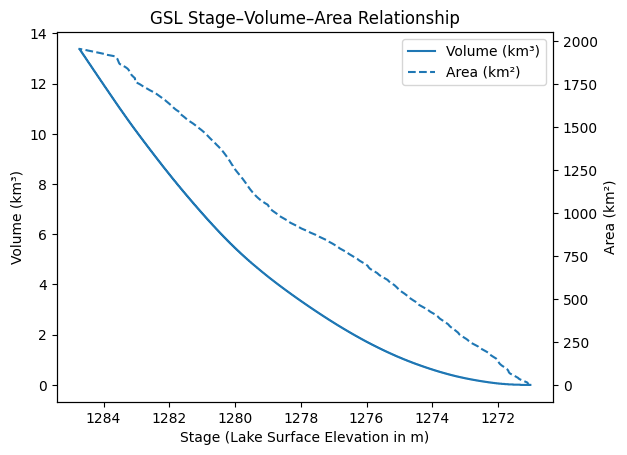

In [82]:
#####
##PLOT THE AREA VOLUME RELATIONSHIP
#####
fig, ax1 = plt.subplots()

# Volume on left axis
line1, = ax1.plot(
    sav["stage_m"],
    sav["volume_km3"],
    label="Volume (km³)"
)
ax1.set_xlabel("Stage (Lake Surface Elevation in m)")
ax1.set_ylabel("Volume (km³)")

# Area on right axis
ax2 = ax1.twinx()
line2, = ax2.plot(
    sav["stage_m"],
    sav["area_km2"],
    linestyle="--",
    label="Area (km²)"
)
ax2.set_ylabel("Area (km²)")

ax1.invert_xaxis()

# combined legend
ax1.legend(
    handles=[line1, line2],
    loc="best"
)

plt.title("GSL Stage–Volume–Area Relationship")
plt.show()


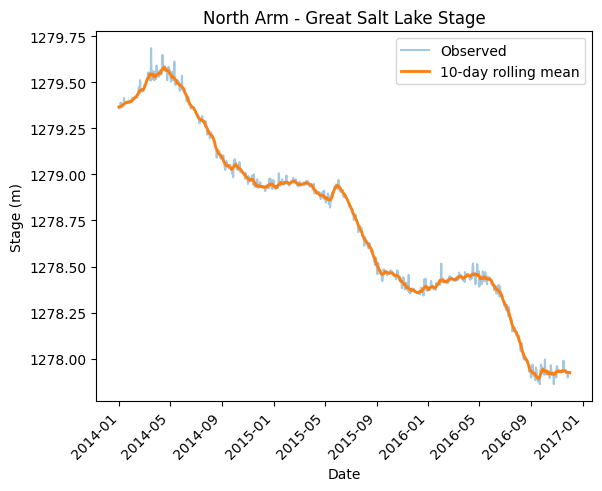

In [83]:
####
##PLOT THE LAKE STAGE
####

# calculate a rolling window to smooth line
window = 10   #days

df["elev_smooth"] = df["elev"].rolling(
    window=window,
    center=True,
    min_periods=1
).mean()

plt.figure()
plt.plot(df["date"], df["elev"], alpha=0.4, label="Observed")
plt.plot(df["date"], df["elev_smooth"], linewidth=2, label=f"{window}-day rolling mean")

plt.xticks(rotation=45, ha="right")
plt.xlabel("Date")
plt.ylabel("Stage (m)")
plt.title("North Arm - Great Salt Lake Stage")
plt.legend()

plt.show()


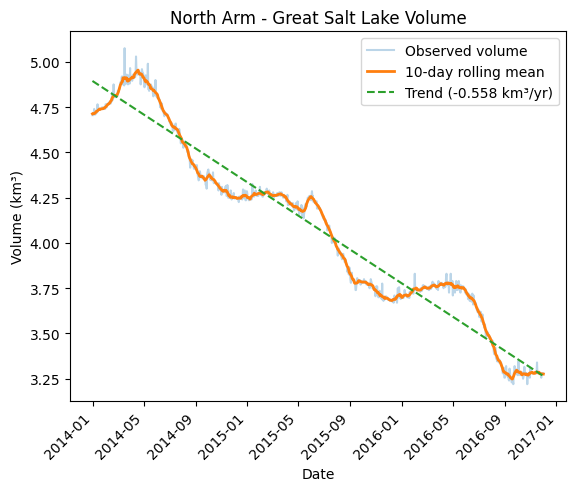

Trend rate (smoothed): -0.5579 km³ per year


In [ ]:
####
##DETERMINE VOLUME OF LAKE FOR EACH DAY, PLOT, DERIVE RATE

# extrapolate volume and area at each daily lake elevation obervation
df["volume_km3"] = np.interp(
    df["elev"].to_numpy(),
    sav["stage_m"].to_numpy(),
    sav["volume_km3"].to_numpy()
)

df["area_km2"] = np.interp(
    df["elev"].to_numpy(),
    sav["stage_m"].to_numpy(),
    sav["area_km2"].to_numpy()
)

#Calculate the daily change in lake volume (forward looking)
df['dv'] = df['volume_km3'] - df['volume_km3'].shift(1)


# smooth volume (rolling mean)
window = 10  # day
df["volume_smooth"] = df["volume_km3"].rolling(
    window=window,
    center=True,
    min_periods=1
).mean()

# fit trend to smoothed volume
mask = df["date"].notna() & df["volume_smooth"].notna()

x_fit = mdates.date2num(df.loc[mask, "date"])
y_fit = df.loc[mask, "volume_smooth"].to_numpy()

m, b = np.polyfit(x_fit, y_fit, 1)

# evaluate trend for all dates
x_all = mdates.date2num(df["date"])
trend = m * x_all + b

# slope in km³/year (m is km³/day)
slope_year = m * 365

# plot
plt.figure()
plt.plot(df["date"], df["volume_km3"], alpha=0.3, label="Observed volume")
plt.plot(df["date"], df["volume_smooth"], linewidth=2, label=f"{window}-day rolling mean")
plt.plot(df["date"], trend, linestyle="--", label=f"Trend ({slope_year:.3f} km³/yr)")

plt.xticks(rotation=45, ha="right")
plt.xlabel("Date")
plt.ylabel("Volume (km³)")
plt.title("North Arm - Great Salt Lake Volume")
plt.legend()

plt.show()

print(f"rate (smoothed): {slope_year:.4f} km³ per year")

In [85]:
####
##LINEAR EXTRAPOLATION TO DERIVE NUMBER OF YEARS FROM CURRENT VOLUME TO 0
####


#Given our rate of volume decline, calculate (linearly) how long it would take for the GSL to go to 0
#years = (Vcurrent - Vtarget) / rate
targetft = 4170
targetft = targetft + 3.47585958 #datum conversion
target = targetft * 0.3048

currentft = 4191.8
currentft = currentft + 3.47585958 #datum conversion
current = currentft * 0.3048


stage_volume = sav[['stage_m','volume_km3']].sort_values('stage_m')


volume_at_current = np.interp(current, stage_volume["stage_m"], stage_volume["volume_km3"])
# volume_at_target = np.interp(target ,stage_volume['stage_m'],stage_volume['volume_km3'])
volume_at_target = 0

print(f"Current volume at current({current}): {volume_at_current}\nVolume at target({target}): {volume_at_target}")
print(f"Difference: {volume_at_current-volume_at_target}km3\nRate: {slope_year}km3 per year")



rate = abs(slope_year)
years = (volume_at_current - volume_at_target) / rate


print(f"Rate: {rate}")
print(f"Years: {years}")

Current volume at current(1278.7200819999841): 4.03
Volume at target(1272.0754419999842): 0
Difference: 4.03km3
Rate: -0.5579081457494202km3 per year
Rate: 0.5579081457494202
Years: 7.223411292170022


0.5067546364664383
k (m/yr): 0.5067546364664383
15.145205479452056


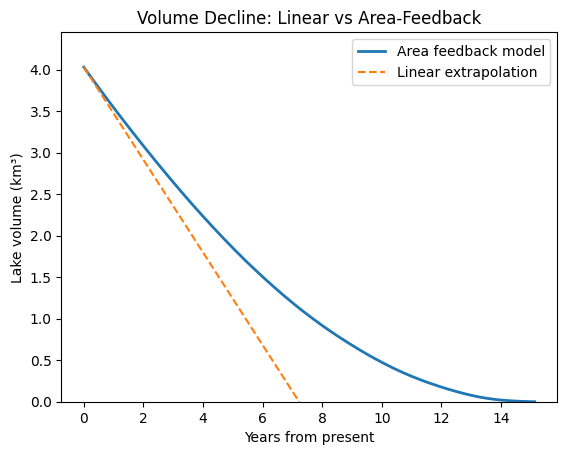

In [ ]:
####
##IMPLEMENT CHANGE IN LAKE AREA INTO PREDICITON
####


# Change in lake depth per day, loss is positive
df["k_m_per_day"] = -(df["dv"] * 1e9) / (df["area_km2"] * 1e6) # change in depth = change in volume (m3) - surface area (m2)

# average daily depth loss, annualized
k_m_per_year = df['k_m_per_day'].mean() * 365
print("k (m/yr):", k_m_per_year)

#ensure the table clean and sorted
stage_volume = sav[["stage_m", "volume_km3", "area_km2"]].dropna().sort_values("stage_m")

#convert to np array
stage_arr = stage_volume["stage_m"].to_numpy()
vol_arr = stage_volume["volume_km3"].to_numpy()
area_arr = stage_volume["area_km2"].to_numpy()

# ensure sorted 
order = np.argsort(vol_arr)
vol_sorted = vol_arr[order]
stage_sorted = stage_arr[order]

V = volume_at_current #same as the linear calc above
days = 0
dt_years = 1 / 356

sim_days = []
sim_stage = []
sim_volume = []
sim_area = []

V = volume_at_current
days = 0
dt_years = 1 / 365.25


while V > volume_at_target:
    #Get elev from running volume
    stage = np.interp(V, vol_sorted, stage_sorted)

    #get area from stage
    area_km2 = np.interp(stage, stage_arr, area_arr)
    area_m2 = area_km2 * 1e6

    # store state
    sim_days.append(days)
    sim_stage.append(stage)
    sim_volume.append(V)
    sim_area.append(area_km2)

    #calculate the change in volume based on the average depth change per year,current area,
    #  and divide by 1/365 to get expected daily volume change
    dV_m3 = k_m_per_year * area_m2 * dt_years

    #subtract estimated daily volume change from the running volume
    V -= dV_m3 / 1e9

    #add 1 to the day counter
    days += 1


years = days / 365
sim_years = np.array(sim_days) / 365.25
print(years)

# linear volume decline for comparison
linear_volume = volume_at_current - abs(slope_year) * sim_years

plt.figure()
plt.plot(sim_years, sim_volume, label="Area feedback model", linewidth=2)
plt.plot(sim_years, linear_volume, "--", label="Linear extrapolation")

plt.xlabel("Years from present")
plt.ylabel("Lake volume (km³)")
plt.ylim(bottom=0)

plt.title("Volume Decline: Linear vs Area-Feedback")
plt.legend()

plt.show()



